In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col


import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

import numpy as np
from scipy.stats import t
from scipy.stats import norm
from scipy.stats import ttest_rel
from numpy.linalg import inv
import warnings
import roman


sns.set_style('whitegrid')
warnings. filterwarnings('ignore')

import rpy2
from rpy2 import robjects
import rpy2.robjects as ro
from rpy2.robjects.packages import importr, data
from rpy2.rinterface_lib.callbacks import logger as rpy2_logger
import logging
rpy2_logger.setLevel(logging.ERROR)

utils = importr('utils')
base = importr('base')
oaxaca = importr('oaxaca')


In [13]:
def convert_pvalue(test, pvalue):
    if pvalue <= 0.01:
        return "${:.3f}".format(test) + '^{***}$'
    elif pvalue <= 0.05:
        return "${:.3f}".format(test) + '^{**}$'
    elif pvalue <= 0.1:
        return "${:.3f}".format(test) + '^{*}$'
    return "${:.3f}$".format(test)


def update_tab(x):
    mean = x[0]
    std = x[1]
    zval = mean/std
    def convert_pvalue(mean, std, pvalue):
        if pvalue <= 0.01:
            significance = ' ^{***}' 
        elif pvalue <= 0.05:
            significance = ' ^{**}'
        elif pvalue <= 0.1:
            significance = ' ^{*}'
        else: 
            significance = ''
        return ['${:.3f}{:s}$'.format(mean, significance), '$({:.3f})$'.format(std)]# "$\\begin{matrix}" + "{:.3f}{:s} \\\\ ({:.3f})".format(mean, significance, std) + "\end{matrix}$"
    return convert_pvalue(mean, std, 2*norm.cdf(-abs(zval)))


def share_gap(x):
    endow = float(x['endowments'].split(" ")[0].replace("$", ""))
    coeff = float(x['coefficients'].split(" ")[0].replace("$", ""))
    inter = float(x['interaction'].split(" ")[0].replace("$", ""))
    total = endow + coeff + inter
    return ['{:.2f}\%'.format(100* (endow/total)), 
            '{:.2f}\%'.format(100* (coeff/total)),
            '{:.2f}\%'.format(100* (inter/total))]


def joinit(iterable, delimiter):
    it = iter(iterable)
    yield next(it)
    for x in it:
        yield delimiter
        yield x

def update_results(resulst_dict_threefold, ind, char, variables_dict, base=[], part='all'):
    columns_names= ['coef(endowments)', 'se(endowments)', 
                    'coef(coefficients)', 'se(coefficients)', 
                    'coef(interaction)', 'se(interaction)']


    df_overall = pd.DataFrame(np.array([resulst_dict_threefold['overall']]), columns = columns_names)
    df_overall['endowments'] = df_overall[['coef(endowments)', 'se(endowments)']].apply(update_tab, axis=1)
    df_overall['coefficients'] = df_overall[['coef(coefficients)', 'se(coefficients)']].apply(update_tab, axis=1)
    df_overall['interaction'] = df_overall[['coef(interaction)', 'se(interaction)']].apply(update_tab, axis=1)
    df_overall = df_overall[['endowments', 'coefficients', 'interaction']]
    df_overall = pd.concat([df_overall[col].explode(ignore_index=True) for col in df_overall], axis="columns")
    df_overall.index = ['Agregate decomposition', '']
    
    df_overall_shared = df_overall.loc['Agregate decomposition'].to_frame().T.apply(lambda x: share_gap(x), axis=1)
    df_overall.loc[len(df_overall.index)] = df_overall_shared.values[0]
    df_overall.loc[len(df_overall.index)] = ['','','']
    df_overall.index = ['Agregate decomposition', '', 'Share of the gap', 'Detailed decomposition']
    
    df_variables = pd.DataFrame(np.array(resulst_dict_threefold['variables']), 
                        index=['constant'] + ind + char + base,
                        columns = columns_names)
    df_variables = df_variables.rename(index=variables_dict)

    df_variables['endowments'] = df_variables[['coef(endowments)', 'se(endowments)']].apply(update_tab, axis=1)
    df_variables['coefficients'] = df_variables[['coef(coefficients)', 'se(coefficients)']].apply(update_tab, axis=1)
    df_variables['interaction'] = df_variables[['coef(interaction)', 'se(interaction)']].apply(update_tab, axis=1)
    df_variables = df_variables[['endowments', 'coefficients', 'interaction']]
    old_index = df_variables.index
    df_variables = pd.concat([df_variables[col].explode(ignore_index=True) for col in df_variables], axis="columns")
    new_index = [""] * (2 * len(old_index) - 1)
    
    df_variables.index = list(joinit(old_index, '')) + ['']
        
    df_results = pd.concat([df_overall, df_variables])
    if part == 'overall':
        return df_overall
    elif part == 'variables':
        return df_variables
    else:
        return df_results

# Read and clean the data

In [5]:
def fix_main_ocupation(x):
    if x not in ['Farming(crop+livestock)', 'Self employed off farm', 'Salaried employment']:
        return 'Other'
    else:
        return x
    
df_M_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Husband Responses.dta')
df_M_raw = df_M_raw[(df_M_raw['A02_Sex'] == 'Male') & 
                    (df_M_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_M_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)

df_F_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/Wife Responses.dta')
df_F_raw = df_F_raw[(df_F_raw['A02_Sex'] == 'Female') &
                    (df_F_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_F_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)


df_allMF = pd.concat([df_M_raw, df_F_raw]).reset_index(drop=True)
both_responses = (df_allMF['HouseID'].value_counts()).to_frame()
both_responses = both_responses[both_responses['HouseID']== 2]
df_allMF = df_allMF[df_allMF['HouseID'].isin(both_responses.index)]
df_allMF = df_allMF.reset_index(drop=True)

df_allMF['A06_Relatn_hhd'] = df_allMF[f'A06_Relatn_hhd'].astype('category')# .cat.codes, 
df_allMF['A07_1_Main_occupatn'] = df_allMF[f'A07_1_Main_occupatn'].astype('category') 
df_allMF['A08_fam_lab_contributn'] = df_allMF['A08_fam_lab_contributn'].apply(lambda x: float(x.replace("%", ""))).astype(float)
df_allMF['A08_fam_lab_contributn'] = df_allMF['A08_fam_lab_contributn'].fillna(0)
df_allMF['A07_1_Main_occupatn'] = df_allMF['A07_1_Main_occupatn'].apply(fix_main_ocupation)
df_allMF['ZoneID'] = df_allMF['ZoneID'].astype(int)

df_M = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_M = df_M.reset_index(drop=True)

df_H = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_H = df_H.reset_index(drop=True)

df_F = df_allMF[df_allMF['A02_Sex'] == 'Female']
df_F = df_F.reset_index(drop=True)

df_H = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/CMS Responses.dta')
df_H = df_H[df_H['HouseID'].isin(df_allMF['HouseID'].value_counts().keys())]
df_H = df_H.reset_index(drop=True)
df_H['A06_Relatn_hhd'] = df_H[f'A06_Relatn_hhd'].astype('category')# .cat.codes, 
df_H['A07_1_Main_occupatn'] = df_H[f'A07_1_Main_occupatn'].astype('category') 
df_H['A08_fam_lab_contributn'] = df_H['A08_fam_lab_contributn'].apply(lambda x: float(x.replace("%", ""))).astype(float)
df_H['A07_1_Main_occupatn'] = df_H['A07_1_Main_occupatn'].apply(fix_main_ocupation)
df_H['ZoneID'] = df_H['ZoneID'].astype(int)


# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_dna = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_dna = df_H_dna[df_H_dna['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_H_dna.columns = ['HouseID', 'ZoneID', 'Household_ICV', 'planted']
df_H_dna['ZoneID'] = (df_H_dna['ZoneID']/10).astype(int)#.tail()
df_H_dna.head()

df_H = df_H.copy()
df_H['A02_Sex'] = 'Yousehold'
df_H['planted'] = df_H_dna['planted']
df_H['Household_ICV'] = df_H_dna['Household_ICV']


clusters = {1: 'A', 2: 'B', 3: 'C', 4: 'D'}


df_FM_test = pd.concat([df_F, df_M])
zoneID = df_FM_test['ZoneID'].apply(lambda x: clusters[x])
df_FM_test = pd.get_dummies(df_FM_test, columns = ['ZoneID', 'A07_1_Main_occupatn'])
df_FM_test['Cluster'] = zoneID
df_FM_test = df_FM_test.rename(columns={
    'A07_1_Main_occupatn_Farming(crop+livestock)': 'A07_1_Main_occupatn_Farming',
    'A07_1_Main_occupatn_Salaried employment': 'A07_1_Main_occupatn_Salaried_employment', 
    'A07_1_Main_occupatn_Self employed off farm': 'A07_1_Main_occupatn_Self_employed_off_farm'
})
df_FM_test['A02_Sex'] = df_FM_test['A02_Sex'].astype('category').cat.codes
df_FM_test.to_csv('../Output/df_FM.csv')

df_FH_test = pd.concat([df_F, df_H])
zoneID = df_FH_test['ZoneID'].apply(lambda x: clusters[x])
df_FH_test = pd.get_dummies(df_FH_test, columns = ['ZoneID', 'A07_1_Main_occupatn'])
df_FH_test['Cluster'] = zoneID

df_FH_test = df_FH_test.rename(columns={
    'A07_1_Main_occupatn_Farming(crop+livestock)': 'A07_1_Main_occupatn_Farming',
    'A07_1_Main_occupatn_Salaried employment': 'A07_1_Main_occupatn_Salaried_employment', 
    'A07_1_Main_occupatn_Self employed off farm': 'A07_1_Main_occupatn_Self_employed_off_farm'
})
df_FH_test['A02_Sex'] = df_FH_test['A02_Sex'].astype('category').cat.codes
df_FH_test.to_csv('../Output/df_FH.csv')

df_MH_test = pd.concat([df_M, df_H])
zoneID = df_MH_test['ZoneID'].apply(lambda x: clusters[x])
df_MH_test = pd.get_dummies(df_MH_test, columns = ['ZoneID', 'A07_1_Main_occupatn'])
df_MH_test['Cluster'] = zoneID

df_MH_test = df_MH_test.rename(columns={
    'A07_1_Main_occupatn_Farming(crop+livestock)': 'A07_1_Main_occupatn_Farming',
    'A07_1_Main_occupatn_Salaried employment': 'A07_1_Main_occupatn_Salaried_employment', 
    'A07_1_Main_occupatn_Self employed off farm': 'A07_1_Main_occupatn_Self_employed_off_farm'
})
df_MH_test['A02_Sex'] = df_MH_test['A02_Sex'].astype('category').cat.codes
df_MH_test.to_csv('../Output/df_MH.csv')

# Select the dependent, independent and household characteristics

In [6]:
dependent = ['planted', 'Household_ICV']
characteristic = ['ZoneID_1', 'ZoneID_2', 'ZoneID_3', #'ZoneID_4',
                  'A03_Age', 'A05_Edu',  
                  'Men_In_House', 'Women_In_House', 'Kids',
                  'A07_1_Main_occupatn_Farming', # 'A07_1_Main_occupatn_Other',
                  'A07_1_Main_occupatn_Salaried_employment',
                  'A07_1_Main_occupatn_Self_employed_off_farm',
                  'A08_fam_lab_contributn']

independent_managed = ['Male_Managed', 'Female_Managed', 'Joint_Managed']
independent_plots = ['Household_Plots', 'J02_per_hh_inc_cassav']
independent_coop_member = ['Men_Only_Coop', 'Women_Only_Coop', 'Joint_Coop']
independent_credit = ['Male_Credit_Only', 'Female_Credit_Only', 'Joint_Credit', 'Credit_Access']
independent_processing = ['Male_Total_Processing_Access', 'Female_Total_Processing_Access', 'Joint_Total_Processing_Access']
independent_asset = ['Total_Household_Asset_Value', 'Women_Owned_HHAsset_Value', 'Male_Owned_HHAsset_Value']
independent_production = ['Male__Production_Value', 'Women__Production_Value', 'Total_Production_Asset_Value']
independent = independent_managed + independent_plots + independent_coop_member + \
independent_asset + independent_credit + independent_processing  + independent_production # + independent_credit


variables_dict = {'planted': 'Y/N ICV', 'Household_ICV': 'Total ICV', 
                  'ZoneID_1': 'Zone 1', 'ZoneID_2': 'Zone 2', 'ZoneID_3': 'Zone 3', 'ZoneID_4': 'Zone 4', 
                  'A03_Age': 'Age', 'A05_Edu': 'Education', 
                  'Men_In_House': 'Men in House', 'Women_In_House': 'Women in House', 'Kids': 'Kids',
                  'A07_1_Main_occupatn_Farming': 'Main occupation: Farming', 
                  'A07_1_Main_occupatn_Salaried_employment': 'Main occupation: Salaried employment', 
                  'A07_1_Main_occupatn_Self_employed_off_farm': 'Main occupation: Self employed off farm', 
                  'A07_1_Main_occupatn_Other': 'Main occupation: Other', 
                  'A08_fam_lab_contributn': 'Contribution to farm work', 
                  'Male_Managed': 'Male Managed', 'Female_Managed': 'Female Managed', 'Joint_Managed': 'Joint Managed', 
                  'Household_Plots': 'Household Plots', 'J02_per_hh_inc_cassav': 'Income from Cassava (%)', 
                  'Men_Only_Coop': 'Men Coop', 'Women_Only_Coop': 'Women Coop', 'Joint_Coop': 'Joint Coop', 
                  'Credit_Access': 'Household Credit', 'Male_Credit_Only': 'Male Credit', 'Female_Credit_Only': 'Female Credit', 'Joint_Credit': 'Joint Credit', 
                  'Male_Total_Processing_Access': 'Male Processing Access', 'Female_Total_Processing_Access': 'Female Processing Access', 'Joint_Total_Processing_Access': 'Joint Processing Access', 
                  'Total_Household_Asset_Value': 'Household Asset', 'Women_Owned_HHAsset_Value': 'Women-owned HH Asset', 'Male_Owned_HHAsset_Value': 'Male-owned HH Asset', 
                  'Male__Production_Value': 'Male Production', 'Women__Production_Value': 'Women Production', 'Total_Production_Asset_Value': 'Total Production'}



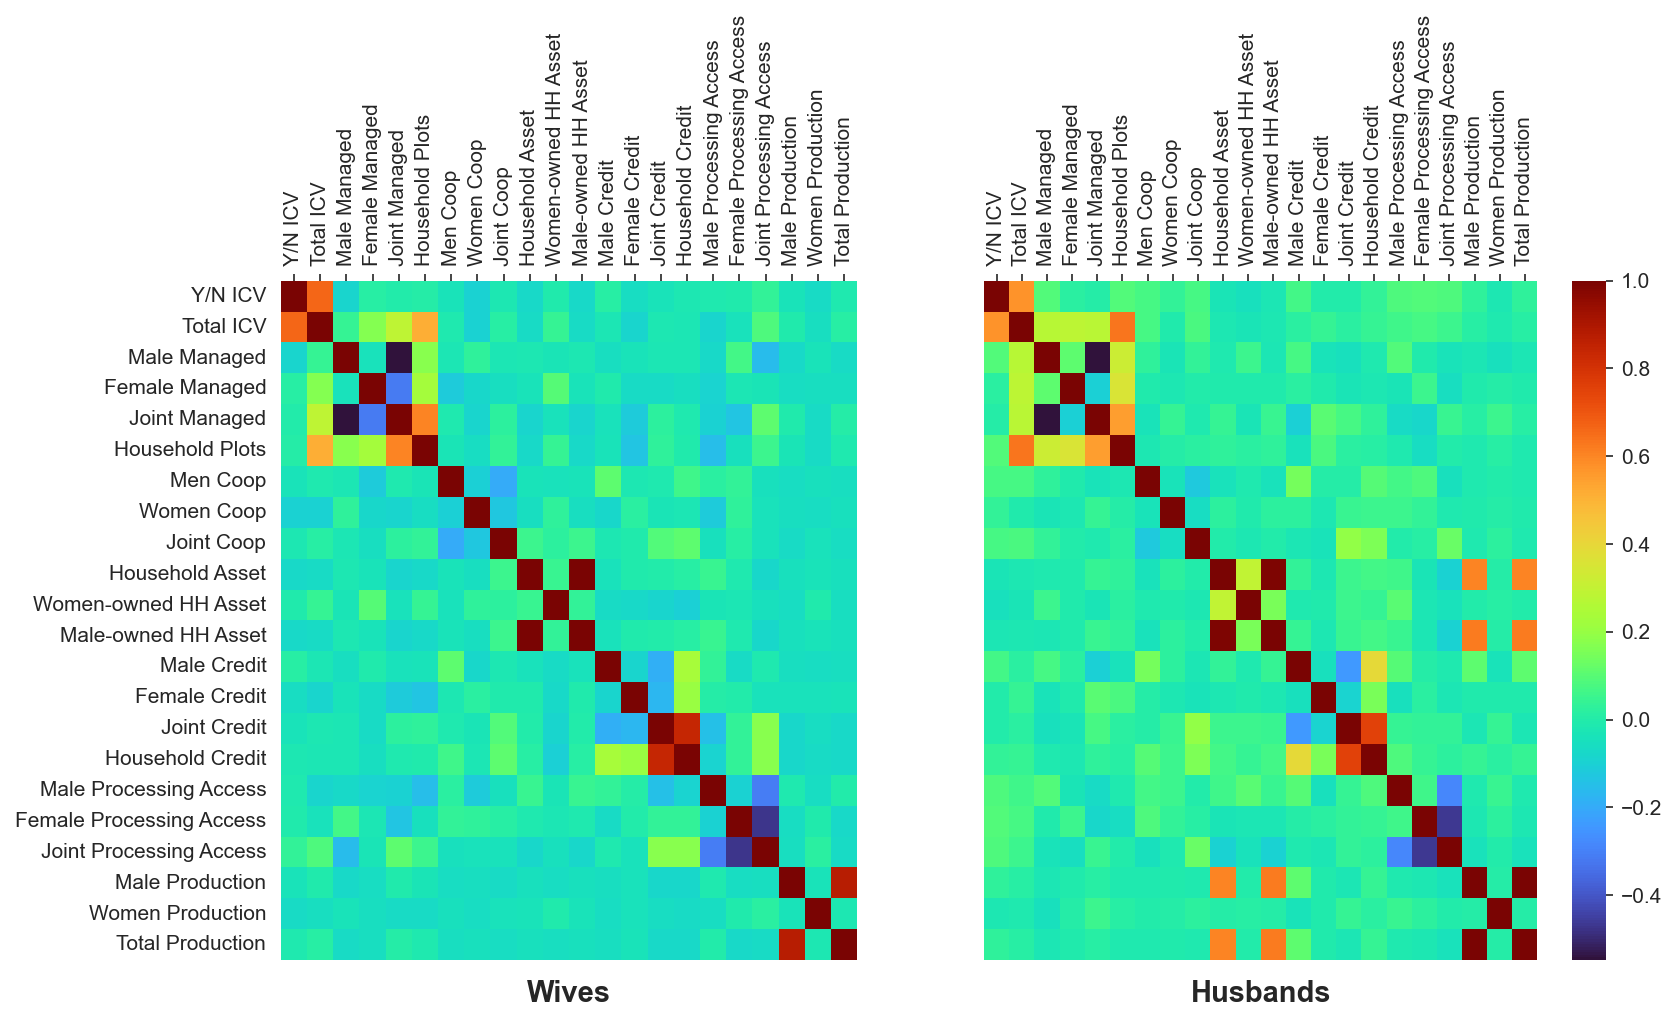

In [7]:
df_F_independent = df_FM_test[df_FM_test['A02_Sex'] == 0][dependent + independent].rename(columns=variables_dict)
df_M_independent = df_FM_test[df_FM_test['A02_Sex'] == 1][dependent + independent].rename(columns=variables_dict)

corr_F = df_F_independent.corr()
corr_M = df_M_independent.corr()

fig3, ax3 = plt.subplots(1, 2, gridspec_kw=dict(width_ratios=[1, 1.2]), figsize=(12, 6), dpi=150)
for index, (corr, df_data) in enumerate(zip([corr_F, corr_M], [df_F_independent, df_M_independent])):
    cb = sns.heatmap(corr, 
                ax=ax3[index],
                xticklabels=corr.columns.values,
                yticklabels=corr.columns.values if index ==0 else [],
                cbar= index == 1, 
                cmap="turbo")    
    ax3[index].xaxis.tick_top()
    ax3[index].set_xticklabels(corr.columns.values, rotation=90)
    ax3[index].set_title('Wives' if index==0 else 'Husbands', y=-0.08, fontweight='bold', fontsize=14)
    
    
fig3.savefig(f"../Output/Figures/corr_wives_husbands.png", dpi=100, bbox_inches='tight' )

In [8]:
df_F_independent = df_FM_test[df_FM_test['A02_Sex'] == 0]#.rename(columns=variables_dict)
df_M_independent = df_FM_test[df_FM_test['A02_Sex'] == 1]#.rename(columns=variables_dict)
df_H_independent = df_FH_test[df_FH_test['A02_Sex'] == 1]#.rename(columns=variables_dict)

data = []
for var in ['planted', 'Household_ICV']:
    for i in characteristic[:3] + ['ZoneID_4']:
        df_F_independent_tmp = df_F_independent[df_F_independent[i] == 1]
        df_M_independent_tmp = df_M_independent[df_M_independent[i] == 1]
        df_H_independent_tmp = df_H_independent[df_H_independent[i] == 1]

        ttest_HM = ttest_rel(df_H_independent_tmp[f'{var}'], df_M_independent_tmp[f'{var}'], nan_policy='omit')
        ttest_HF = ttest_rel(df_H_independent_tmp[f'{var}'], df_F_independent_tmp[f'{var}'], nan_policy='omit')
        ttest_MF = ttest_rel(df_M_independent_tmp[f'{var}'], df_F_independent_tmp[f'{var}'], nan_policy='omit')

        data.append(['\qquad ' + variables_dict[i], convert_pvalue(df_H_independent_tmp[var].mean(), 1),
                     convert_pvalue(df_M_independent_tmp[var].mean(), 1),
                     convert_pvalue(df_F_independent_tmp[var].mean(), 1),
                     convert_pvalue(ttest_HM[0], ttest_HM[1]), 
                     convert_pvalue(ttest_HF[0], ttest_HF[1]), 
                     convert_pvalue(ttest_MF[0], ttest_MF[1])])
    
print(pd.DataFrame(data).to_latex(escape=False, index=False))

\begin{tabular}{lllllll}
\toprule
            0 &       1 &       2 &       3 &             4 &             5 &             6 \\
\midrule
\qquad Zone 1 & $0.597$ & $0.640$ & $0.656$ &      $-0.905$ &      $-1.209$ &      $-0.419$ \\
\qquad Zone 2 & $0.693$ & $0.697$ & $0.597$ &      $-0.094$ &  $2.142^{**}$ & $2.755^{***}$ \\
\qquad Zone 3 & $0.503$ & $0.370$ & $0.358$ & $2.639^{***}$ & $2.810^{***}$ &       $0.470$ \\
\qquad Zone 4 & $0.793$ & $0.764$ & $0.721$ &       $0.631$ &       $1.590$ &       $1.227$ \\
\qquad Zone 1 & $1.586$ & $1.204$ & $1.333$ & $4.342^{***}$ &   $1.961^{*}$ &      $-1.164$ \\
\qquad Zone 2 & $1.660$ & $1.773$ & $1.555$ &      $-1.375$ &       $0.722$ &   $1.690^{*}$ \\
\qquad Zone 3 & $1.909$ & $1.267$ & $1.055$ & $3.481^{***}$ & $4.400^{***}$ &       $1.290$ \\
\qquad Zone 4 & $2.064$ & $1.764$ & $1.579$ &  $2.379^{**}$ & $3.334^{***}$ &       $1.622$ \\
\bottomrule
\end{tabular}



# Run the regressions with the selected independent

In [9]:
dependent = ['planted', 'Household_ICV']
characteristic = ['ZoneID_1', 'ZoneID_2', 'ZoneID_3', #'ZoneID_4',
                  'A03_Age', 'A05_Edu',  
                  'Men_In_House', 'Women_In_House', 'Kids',
                  #'A07_1_Main_occupatn_Farming', # 'A07_1_Main_occupatn_Other',
                  #'A07_1_Main_occupatn_Salaried_employment', 'A07_1_Main_occupatn_Self_employed_off_farm',
                  'A08_fam_lab_contributn'
                 ]

independent_managed = ['Joint_Managed']
independent_coop_member = ['Joint_Coop']
independent_credit =  ['Joint_Credit']
independent_processing = ['Joint_Total_Processing_Access']
# independent_production = ['Total_Household_Asset_Value']
independent = independent_managed + independent_coop_member + independent_credit + independent_processing  # + independent_production # + independent_credit

In [15]:
df_F_independent = df_FM_test[df_FM_test['A02_Sex'] == 0].rename(columns=variables_dict)
df_M_independent = df_FM_test[df_FM_test['A02_Sex'] == 1].rename(columns=variables_dict)
df_H_independent = df_FH_test[df_FH_test['A02_Sex'] == 1].rename(columns=variables_dict)

ind = list(map(lambda x: variables_dict[x], independent))
char = list(map(lambda x: variables_dict[x], characteristic))
dep =  list(map(lambda x: variables_dict[x], dependent))
zones = char[:3]
print(ind)
#char = char[3:]


results = []
#for zone in zones[:3] + ['Zone 4']:
df_F_independent_tmp = df_F_independent.copy()
#df_F_independent_tmp[ind] = df_F_independent_tmp[ind].astype(float)#[df_F_independent[zone]==1]

df_M_independent_tmp  = df_M_independent.copy()
#df_M_independent_tmp[ind]  = df_F_independent[ind].astype(float)#[df_M_independent[zone]==1]

df_H_independent_tmp  = df_H_independent.copy()#[df_H_independent[zone]==1]
#df_H_independent_tmp[ind]  = df_H_independent[ind].astype(float)#[df_H_independent[zone]==1]


for y in dep:
    Y = df_F_independent_tmp[y]
    X = sm.add_constant(df_F_independent_tmp[ind + char], prepend=False)
    model_F = sm.Probit(Y,X) if y == 'Y/N ICV' else sm.OLS(Y,X)
    results_F = model_F.fit(cov_type='cluster', cov_kwds={'groups': df_F_independent_tmp['Cluster'].values}, maxiter=100, )
    results.append(results_F)

    Y = df_M_independent_tmp[y]
    X = sm.add_constant(df_M_independent_tmp[ind + char], prepend=False)
    model_M = sm.Probit(Y,X) if y == 'Y/N ICV' else sm.OLS(Y,X)
    results_M = model_M.fit(cov_type='cluster', cov_kwds={'groups': df_F_independent_tmp['Cluster'].values}, maxiter=100, )
    results.append(results_M)

    Y = df_H_independent_tmp[y]
    X = sm.add_constant(df_H_independent_tmp[ind + char], prepend=False)
    model_H = sm.Probit(Y,X) if y == 'Y/N ICV' else sm.OLS(Y,X)
    results_H = model_H.fit(cov_type='cluster', cov_kwds={'groups': df_F_independent_tmp['Cluster'].values}, maxiter=100, )
    results.append(results_H)

columns_dataset = {0: 'Wives', 1: "Husband", 2: "Household"}

summary_str  = summary_col(results, 
                  stars=True,
                  model_names=[columns_dataset[i%3] for i in range(1, len(results)+1)],
                  float_format='%.3f',
                  info_dict={
                      'N':lambda x: "{0:d}".format(int(x.nobs))
                  },
                  regressor_order=ind + char
                          ).as_latex()

print(summary_str)

['Joint Managed', 'Joint Coop', 'Joint Credit', 'Joint Processing Access']
Optimization terminated successfully.
         Current function value: 0.636403
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.607187
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.621896
         Iterations 5
\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllll}
\hline
                          & Husband I & Household I & Wives I   & Husband II & Household II & Wives II   \\
\hline
Joint Managed             & 0.042**   & 0.054**     & -0.043    & 0.315***   & 0.330***     & 0.292***   \\
                          & (0.017)   & (0.026)     & (0.044)   & (0.087)    & (0.061)      & (0.059)    \\
Joint Coop                & -0.001    & 0.197***    & 0.056     & 0.051      & 0.287***     & 0.195      \\
                          & (0.168)   & (0.055)     & (0.130)   & (0.154)    & (0.072)      & (0.20

# Run the regressions by Zone

In [14]:
df_F_independent = df_FM_test[df_FM_test['A02_Sex'] == 0].rename(columns=variables_dict)
df_M_independent = df_FM_test[df_FM_test['A02_Sex'] == 1].rename(columns=variables_dict)
df_H_independent = df_FH_test[df_FH_test['A02_Sex'] == 1].rename(columns=variables_dict)

ind = list(map(lambda x: variables_dict[x], independent))
char = list(map(lambda x: variables_dict[x], characteristic))
dep =  list(map(lambda x: variables_dict[x], dependent))
zones = char[:3]
char = char[3:]

columns_dataset = {0: 'Wives', 1: "Husband", 2: "Household"}

for y in dep:
    results = []
    for zone in zones[:3] + ['Zone 4']:
        df_F_independent_tmp = df_F_independent[df_F_independent[zone]==1]
        df_M_independent_tmp  = df_M_independent[df_M_independent[zone]==1]
        df_H_independent_tmp  = df_H_independent[df_H_independent[zone]==1]


        Y = df_F_independent_tmp[y]
        X = sm.add_constant(df_F_independent_tmp[ind + char], prepend=False)
        model_F = sm.Probit(Y,X, offset=True,  missing='drop') if y == 'Y/N ICV' else sm.OLS(Y,X)
        results_F = model_F.fit(cov_type='HC0', maxiter=10000)
        results.append(results_F)

        Y = df_M_independent_tmp[y]
        X = sm.add_constant(df_M_independent_tmp[ind + char], prepend=False)
        model_M = sm.Probit(Y,X, offset=True, missing='drop') if y == 'Y/N ICV' else sm.OLS(Y,X)
        results_M = model_M.fit(cov_type='HC0', maxiter=10000)
        results.append(results_M)

        Y = df_H_independent_tmp[y]
        X = sm.add_constant(df_H_independent_tmp[ind + char], prepend=False)
        model_H = sm.Probit(Y,X, offset=True,  missing='drop') if y == 'Y/N ICV' else sm.OLS(Y,X)
        results_H = model_H.fit(cov_type='HC0', maxiter=10000)
        results.append(results_H)

    summary_str  = summary_col(results, 
                      stars=True,
                      model_names=[columns_dataset[i%3] for i in range(0, len(results))],
                      float_format='%.3f',
                      info_dict={
                          'N':lambda x: "{0:d}".format(int(x.nobs))
                      },
                      regressor_order=ind + char
                              ).as_latex()

    print("---------------------")
    print(y)
    print(summary_str)
    print("\n\n\n")

Optimization terminated successfully.
         Current function value: 0.601464
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.623192
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.640936
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.645929
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.589743
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.578022
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.612127
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.642102
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.667617
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.554214
  

In [83]:
dependent = ['planted', 'Household_ICV']
characteristic = ['ZoneID_1', 'ZoneID_2', 'ZoneID_3', #'ZoneID_4',
                  'A03_Age', 'A05_Edu',  
                  'Men_In_House', 'Women_In_House', 'Kids',
                  #'A07_1_Main_occupatn_Farming', # 'A07_1_Main_occupatn_Other',
                  #'A07_1_Main_occupatn_Salaried_employment', 'A07_1_Main_occupatn_Self_employed_off_farm',
                  'A08_fam_lab_contributn']

independent_managed = ['Joint_Managed']
independent_coop_member = ['Joint_Coop']
independent_credit = ['Joint_Credit']
independent_processing = ['Joint_Total_Processing_Access']
independent_production = ['Total_Household_Asset_Value']

independent_managed = ['Female_Managed']#['Joint_Managed']
independent_coop_member = ['Women_Only_Coop']#['Joint_Coop']
independent_credit = ['Female_Credit_Only']#['Joint_Credit']
independent_processing = ['Female_Total_Processing_Access']#['Joint_Total_Processing_Access']

independent = independent_managed + independent_coop_member + independent_credit + independent_processing  # + independent_production # + independent_credit

# Oaxaca for Group A vs Group B

In [17]:
df_results = []

## Select the group A and B
groupA = 'F' # Female
groupB = 'M' # Male
dataset = f'{groupA}{groupB}'

for y in ['planted', 'Household_ICV']:
    group = 'A02_Sex'
    formula = f'{y} ~ ' + ' + '.join(independent) + " + " + ' + '.join(characteristic) + f' | {group} ' + \
                ' | ' + ' + '.join(characteristic[:3])
    #formula = f'{dependent} ~ ' + ' + '.join(independent)  +  f' | {group}' 
    extra = 'reg.fun = glm, family = binomial(link = "probit")' if dependent == 'planted' else ''
    
    # print(formula)
    robjects.r(f''' 
        df <- read.csv("../Output/df_{dataset}.csv")
        results <- oaxaca(formula = {formula}, data=df, {extra}, R=100)

    ''')


    results = robjects.globalenv['results']
    resulst_dict = dict(zip(results.names, results))
    resulst_dict_threefold = dict(zip(resulst_dict['threefold'].names, 
                                      list(resulst_dict['threefold'])))
    
    results_dict_y =dict(zip(resulst_dict['y'].names, resulst_dict['y']))
    print(y, '\t'
          'Group A = ', '{:.3f}'.format(results_dict_y['y.A'][0]), 
          ', Group B = ',   '{:.3f}'.format(results_dict_y['y.B'][0]), 
          ', Mean gender gap=', '{:.3f}'.format(results_dict_y['y.diff'][0])) 
    
    df_tmp = update_results(resulst_dict_threefold, independent, characteristic, base =['(Base)'], 
                            variables_dict=variables_dict)
    df_tmp.columns = pd.MultiIndex.from_product([[y], df_tmp.columns])
    df_results.append(df_tmp)
    
print(pd.concat(df_results, axis=1).to_latex(escape=False))

planted 	Group A =  0.582 , Group B =  0.621 , Mean gender gap= -0.040
Household_ICV 	Group A =  1.390 , Group B =  1.512 , Mean gender gap= -0.122
\begin{tabular}{lllllll}
\toprule
{} & \multicolumn{3}{l}{planted} & \multicolumn{3}{l}{Household_ICV} \\
{} &     endowments & coefficients & interaction &      endowments &   coefficients &    interaction \\
\midrule
Agregate decomposition    &       $-0.013$ &      $0.002$ &    $-0.029$ &         $0.083$ &       $-0.029$ &       $-0.176$ \\
                          &      $(0.022)$ &    $(0.031)$ &   $(0.030)$ &       $(0.082)$ &      $(0.117)$ &      $(0.111)$ \\
Share of the gap          &        32.50\% &      -5.00\% &     72.50\% &        -68.03\% &        23.77\% &       144.26\% \\
Detailed decomposition    &                &              &             &                 &                &                \\
constant                  &        $0.000$ &     $-0.149$ &    $-0.000$ &         $0.000$ &       $-0.703$ &       $-0.000$ \

# Oaxaca for Group A vs Group B by Zone

In [19]:


## Select the group A and B
groupA = 'F' # Female
groupB = 'M' # Male
dataset = f'{groupA}{groupB}'

for y in ['planted', 'Household_ICV']:
    df_results = []
    for zone in characteristic[:3] + ['ZoneID_4']:
        group = 'A02_Sex'
        formula = f'{y} ~ ' + ' + '.join(independent) + " + " + ' + '.join(characteristic[3:]) + f' | {group}' 
        #formula = f'{dependent} ~ ' + ' + '.join(independent)  +  f' | {group}' 
        # print(formula)
        extra = 'reg.fun = glm, family = binomial(link = "probit")' if y == 'planted' else ''

        # print(formula)
        robjects.r(f''' 
            library(oaxaca);
            df <- read.csv("../Output/df_{dataset}.csv")
            df <- df[which(df${zone}==1), ]
            results <- oaxaca(formula = {formula}, data=df, {extra}, R=100)
        ''')

        results = robjects.globalenv['results']

        resulst_dict = dict(zip(results.names, results))
        resulst_dict_threefold = dict(zip(resulst_dict['threefold'].names, 
                                          list(resulst_dict['threefold'])))

        results_dict_y =dict(zip(resulst_dict['y'].names, resulst_dict['y']))
        print(y, '\t'
              'Group A = ', '{:.3f}'.format(results_dict_y['y.A'][0]), 
              ', Group B = ',   '{:.3f}'.format(results_dict_y['y.B'][0]), 
              ', Mean gender gap=', '{:.3f}'.format(results_dict_y['y.diff'][0])) 

        # print(resulst_dict_threefold)
        # df_tmp = update_results(resulst_dict_threefold, independent, characteristic, variables_dict)

        df_tmp = update_results(resulst_dict_threefold, independent, characteristic[3:], base =[], 
                            variables_dict=variables_dict)
        
        df_tmp.columns = pd.MultiIndex.from_product([[zone], df_tmp.columns])
        df_results.append(df_tmp)
    
    
    print(pd.concat(df_results, axis=1).to_latex(escape=False))
    print("\n\n\n")
    #pd.concat(df_results, axis=1)# .to_latex(escape=False)

planted 	Group A =  0.656 , Group B =  0.640 , Mean gender gap= 0.016
planted 	Group A =  0.597 , Group B =  0.697 , Mean gender gap= -0.101
planted 	Group A =  0.358 , Group B =  0.370 , Mean gender gap= -0.012
planted 	Group A =  0.721 , Group B =  0.764 , Mean gender gap= -0.043
\begin{tabular}{lllllllllllll}
\toprule
{} & \multicolumn{3}{l}{ZoneID_1} & \multicolumn{3}{l}{ZoneID_2} & \multicolumn{3}{l}{ZoneID_3} & \multicolumn{3}{l}{ZoneID_4} \\
{} & endowments & coefficients & interaction &      endowments & coefficients & interaction & endowments &   coefficients & interaction & endowments & coefficients & interaction \\
\midrule
Agregate decomposition    &   $-0.025$ &      $0.030$ &     $0.063$ &        $-0.084$ &     $-0.027$ &    $-0.173$ &    $0.113$ &        $0.160$ &    $-0.323$ &   $-0.077$ &     $-0.023$ &    $-0.016$ \\
                          &  $(0.204)$ &    $(0.256)$ &   $(0.294)$ &       $(0.116)$ &    $(0.196)$ &   $(0.178)$ &  $(0.114)$ &      $(0.219)$ &   $(0.